In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## Setup

In [2]:
def create_all_or_none(p, iterations):
    graph = np.zeros((iterations, iterations),dtype=np.int32)

    for i in range(1, iterations):
        idx = np.random.randint(i)
        if np.random.rand() < p:
            graph[:, i] = graph[:, idx]
            graph[i, :] = graph[idx, :]
            graph[i, idx] = 1
            graph[idx, i] = 1
        else:
            graph[idx, i] = 1
            graph[i, idx] = 1
    return graph

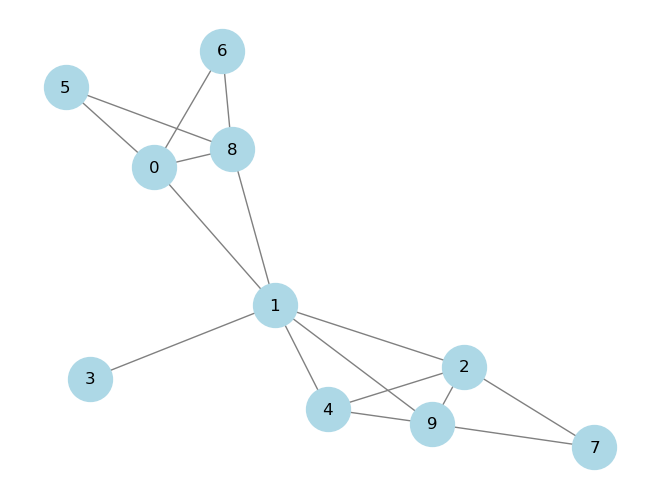

In [3]:
graph = create_all_or_none(0.5, 10)

G = nx.from_numpy_array(graph)
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1000)
plt.show()

## Total Edges

In [4]:
def all_or_none_recur(p, n):
    if n == 1 or n == 2:
        return n - 1
    prev = all_or_none_recur(p, n - 1)
    return prev + 1 + 2 * p * prev / (n - 1)

def all_or_none_loop(p, n):
    if n == 1:
        return 0

    e = 1

    for t in range(3, n + 1):
        e += 1 + 2 * p * e / (t - 1)

    return e

1636.819
1636.899063933106


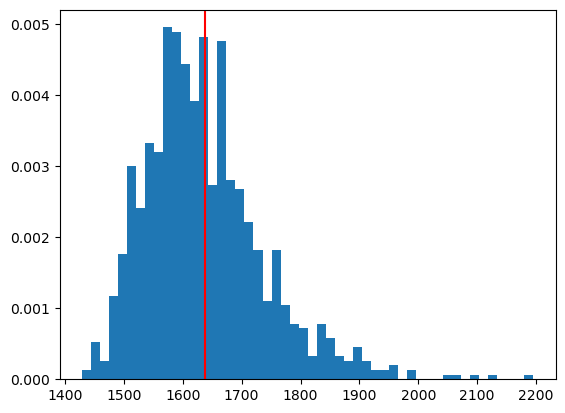

In [5]:
trials = 1000
edges = []

p = 0.2
n = 1000

for i in range(trials):
    edges += [np.count_nonzero(create_all_or_none(p, n)) / 2]

print(np.mean(edges))
expected = all_or_none_recur(p, n)
print(expected)
plt.hist(edges, density=True, bins=50)
plt.axvline(expected, color='red')

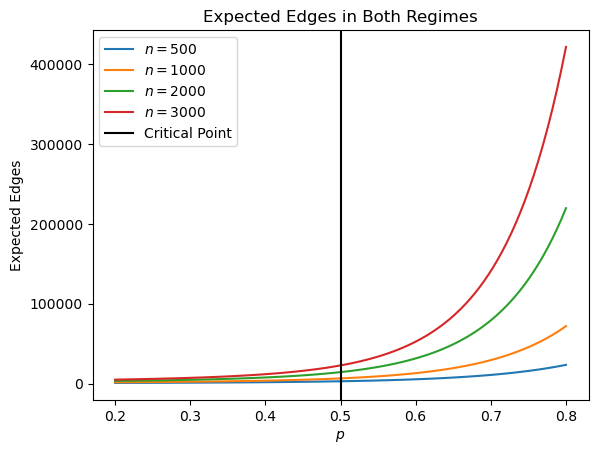

In [6]:
ps = np.linspace(0.2, 0.8, 100)
n500 = np.vectorize(lambda x : all_or_none_loop(x, 500))(ps)
n1000 = np.vectorize(lambda x : all_or_none_loop(x, 1000))(ps)
n2000 = np.vectorize(lambda x : all_or_none_loop(x, 2000))(ps)
n3000 = np.vectorize(lambda x : all_or_none_loop(x, 3000))(ps)

plt.plot(ps, n500, label="$n=500$")
plt.plot(ps, n1000, label="$n=1000$")
plt.plot(ps, n2000, label="$n=2000$")
plt.plot(ps, n3000, label="$n=3000$")
plt.axvline(0.5, color="black", label="Critical Point")
plt.legend()
plt.xlabel("$p$")
plt.ylabel("Expected Edges")
plt.title("Expected Edges in Both Regimes")
plt.show()

## Degrees

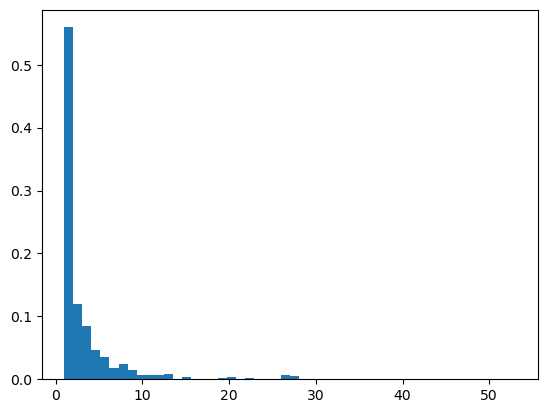

In [7]:
p, n = 0.2, 2000
graph = create_all_or_none(p, n)

G = nx.from_numpy_array(graph)

degrees = [d for _, d in G.degree()]
plt.hist(degrees, bins=50, density=True)
plt.show()

In [8]:
def degree_recur(p, n):
    dk = np.zeros(n - 1)
    dk[0] = 2
    for t in range(2, n):
        dk_new = np.copy(dk)
        dk_new[0] = dk[0] - (1 + p) / t * dk[0] + (1 - p)
        for i in range(1, len(dk_new)):
            k = i + 1
            dk_new[i] = dk[i] + (1 + p * k) / t * dk[i - 1] - (1 + p * k) / t * dk[i]
        dk = dk_new

    return dk

In [9]:
degree_recur(0.2, 2000)

array([727.27284688, 424.2431115 , 261.0745017 , ...,   0.        ,
         0.        ,   0.        ], shape=(1999,))

[0.36363642 0.21212156 0.13053725 ... 0.         0.         0.        ]


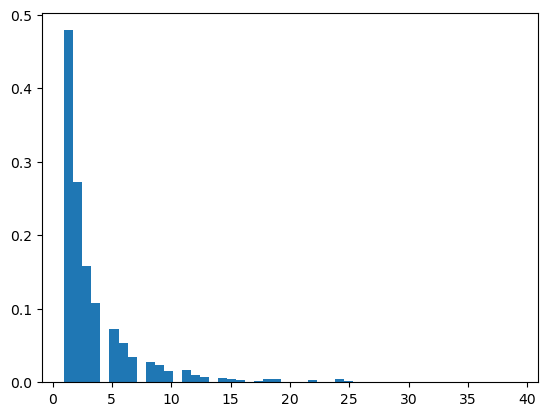

In [10]:
p, n = 0.2, 2000
graph = create_all_or_none(p, n)

G = nx.from_numpy_array(graph)

theory = degree_recur(0.2, 2000)
theory /= np.sum(theory)

print(theory)

degrees = [d for _, d in G.degree()]
plt.hist(degrees, bins=50, density=True)
plt.show()

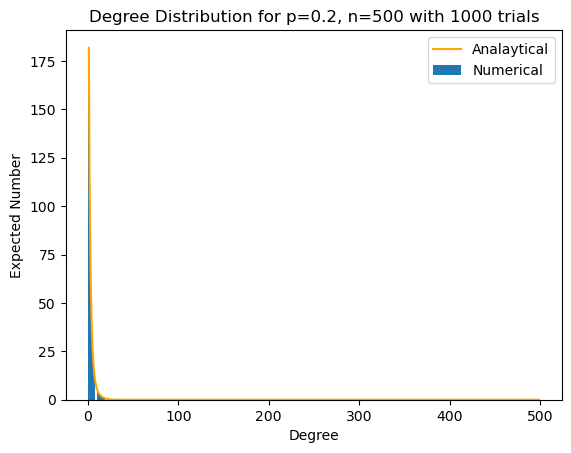

In [11]:
from collections import Counter
cnt = Counter()
trials = 1000

p, n, cutoff = 0.2, 500, 500
dk = np.zeros(n - 1)

for _ in range(trials):
    graph = create_all_or_none(p, n)
    G = nx.from_numpy_array(graph)
    for _, d in G.degree():
        dk[d - 1] += 1

dk /= trials
x = np.arange(cutoff - 1) + 1
plt.bar(x, dk[:cutoff], label="Numerical")
plt.plot(x, degree_recur(p, n)[:cutoff], color="orange", label="Analaytical")
plt.title(f"Degree Distribution for p={p}, n={n} with {trials} trials")
plt.xlabel("Degree")
plt.ylabel("Expected Number")
plt.legend()

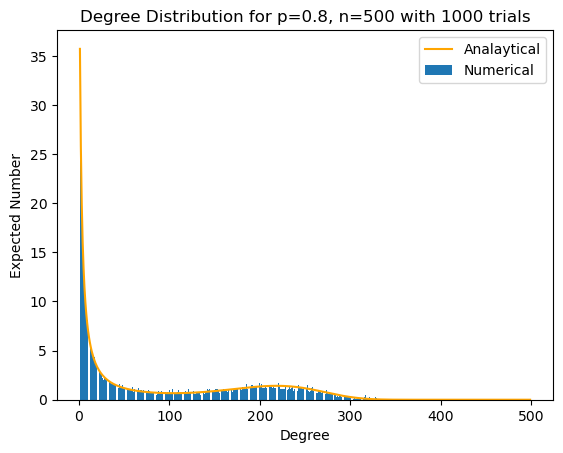

In [12]:
from collections import Counter
cnt = Counter()
trials = 1000

p, n, cutoff = 0.8, 500, 500
dk = np.zeros(n - 1)

for _ in range(trials):
    graph = create_all_or_none(p, n)
    G = nx.from_numpy_array(graph)
    for _, d in G.degree():
        dk[d - 1] += 1

dk /= trials
x = np.arange(cutoff - 1) + 1
plt.bar(x, dk[:cutoff], label="Numerical")
plt.plot(x, degree_recur(p, n)[:cutoff], color="orange", label="Analaytical")
plt.title(f"Degree Distribution for p={p}, n={n} with {trials} trials")
plt.xlabel("Degree")
plt.ylabel("Expected Number")
plt.legend()

## Triangles

In [13]:
def triangle_recur(p, n):
    if n < 3:
        return 0

    tn = 0
    en = 1
    for t in range(3, n + 1):
        tn += p * (2 * en / (t - 1) + 3 * tn / (t - 1))
        en += 1 + 2 * p * en / (t - 1)
    return tn


166.829
647.225
2121.54
7377.978
25574.351
98031.219
370497.129


Text(0, 0.5, 'Expected Triangles')

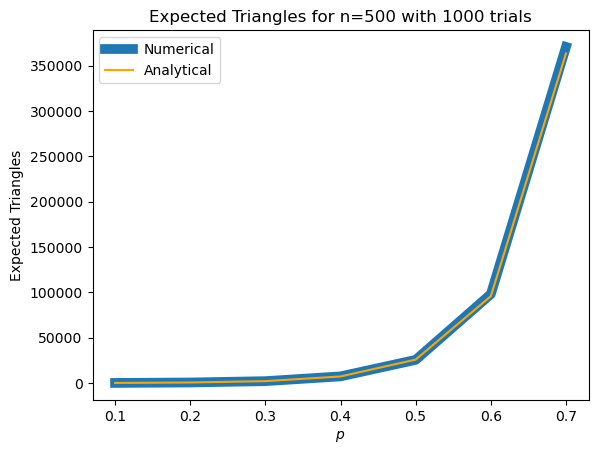

In [14]:
trials = 1000
triangles = []

p_list = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
t_list = np.zeros(len(p_list))
n = 500
expected = triangle_recur(p_list, n)

for i, p in enumerate(p_list):
    for _ in range(trials):
        graph = create_all_or_none(p, n)
        G = nx.from_numpy_array(graph)
        t_list[i] += sum(nx.triangles(G).values()) // 3
    t_list[i] /= trials
    print(t_list[i])

plt.plot(p_list, t_list, label="Numerical", linewidth=7.0)
plt.plot(p_list, expected, color="orange", label="Analytical")
plt.legend()
plt.title(f"Expected Triangles for n={n} with {trials} trials")
plt.xlabel("$p$")
plt.ylabel("Expected Triangles")


## Global Clustering

In [15]:
def trails_loop(p, n):
    if n < 3:
        return 0
    wn = 0
    prev = 1

    for t in range(3, n + 1):
        wn += 2 * prev / (t - 1) + p / (t - 1) * (3 * wn + 4 * prev)
        prev += 1 + 2 * p * prev / (t - 1)

    return wn
    
def cluster_recur(p, n):
    return 3 * triangle_recur(p, n) / trails_loop(p, n)

0.2443892358614452
0.4147174831559515
0.544428742818979
0.6377142600036878
0.7162188932618239
0.7855360921142672
0.8467303152303867


Text(0, 0.5, 'Expected Clustering')

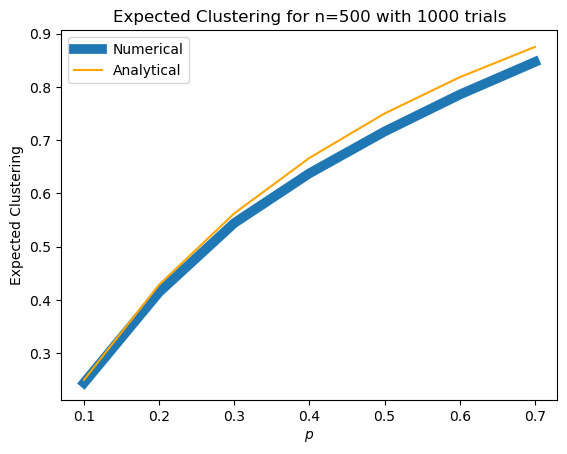

In [16]:
trials = 1000

p_list = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
t_list = np.zeros(len(p_list))
n = 500
expected = cluster_recur(p_list, n)

for i, p in enumerate(p_list):
    for _ in range(trials):
        graph = create_all_or_none(p, n)
        G = nx.from_numpy_array(graph)
        t_list[i] += nx.transitivity(G)
    t_list[i] /= trials
    print(t_list[i])

plt.plot(p_list, t_list, label="Numerical", linewidth=7.0)
plt.plot(p_list, expected, color="orange", label="Analytical")
plt.legend()
plt.title(f"Expected Clustering for n={n} with {trials} trials")
plt.xlabel("$p$")
plt.ylabel("Expected Clustering")

## Assortativity

In [17]:
%%time

def _add_edge(E, a, b, w):
    # Adds w edges from degree a to degree b
    if w <= 0:
        return
    if a == b:
        E[a, a] += 2.0 * w
    else:
        E[a, b] += w
        E[b, a] += w

def _move_class(E, a, b, vec):
    # Moves a vector from one degree to another
    if a == b:
        return
    E[a, :] -= vec
    E[:, a] -= vec
    E[b, :] += vec
    E[:, b] += vec

def step_stub_matrix(E, p):
    # Diagonal entries are doubled
    E_old = np.asarray(E, dtype=float)
    K = E_old.shape[0]
    E_new = E_old.copy()

    deg = np.arange(1, K + 1, dtype=float)
    row_sum = E_old.sum(axis=1)
    d = np.divide(row_sum, deg, out=np.zeros_like(row_sum), where=deg > 0)
    n_nodes = d.sum()

    if n_nodes <= 0:
        return E_new

    for s in range(K - 1):
        if d[s] <= 0:
            continue

        seed_prob = d[s] / n_nodes

        # We always move the selected node up a degree
        # Then we move a proportional amount of stubs as well
        seed_move = E_old[s, :] / n_nodes
        _move_class(E_new, s, s + 1, seed_move)

        # no copy
        _add_edge(E_new, 0, s + 1, seed_prob * (1.0 - p))

        # copy
        if p > 0:
            # always increase the degree of the node its connected to
            _add_edge(E_new, s + 1, s + 1, seed_prob * p)

            # copy the neighbours to edit
            for r in range(K - 1):
                if d[r] <= 0:
                    continue

                cnt = p * E_old[s, r] / n_nodes
                if cnt <= 0:
                    continue

                # each neighbor increases the degree
                move_r = cnt * E_old[r, :] / d[r]
                _move_class(E_new, r, r + 1, move_r)

                # each neighbour gains an edge to the new node
                _add_edge(E_new, s + 1, r + 1, cnt)

    E_new = 0.5 * (E_new + E_new.T)
    E_new[E_new < 0] = 0.0
    return E_new

def evolve_stub_matrix(p, n):
    E = np.zeros((n - 1, n - 1), dtype=float)
    E[0, 0] = 2.0 

    for _ in range(2, n):
        E = step_stub_matrix(E, p)

    return E

def assortativity_from_stub_matrix(E):
    E = np.asarray(E, dtype=float)
    m = E.sum()
    if m <= 0:
        return np.nan

    k = np.arange(E.shape[0], dtype=float)
    a = E.sum(axis=1) / m

    mu = np.sum(k * a)
    mu2 = np.sum((k ** 2) * a)
    var = mu2 - mu ** 2
    if var <= 1e-15:
        return np.nan

    kk = np.sum((k[:, None] * k[None, :]) * E) / m
    print("DONE")
    return (kk - mu ** 2) / var

p, n = 0.2, 1000
E = evolve_stub_matrix(p, n)
r = assortativity_from_stub_matrix(E)
print(r)

DONE
0.45991273213099
CPU times: user 19min 36s, sys: 36.6 ms, total: 19min 36s
Wall time: 19min 38s


DONE
DONE
DONE
DONE
DONE
DONE
DONE
DONE
-0.14883989853002322 -0.1481381213443297
0.022595243578127384 0.07994577024200218
0.14001143836906962 0.21070230831628697
0.2098238083628478 0.2792917700430533
0.25881430293257035 0.3043593422426076
0.29453151126423927 0.2945996444060673
0.3127893698662835 0.25158884851935925
0.309973070456558 0.16980175781226003


Text(0, 0.5, 'Expected Assortativity')

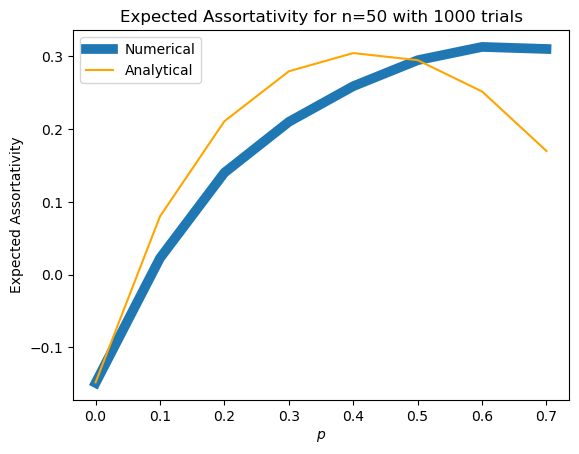

In [18]:
trials = 1000

p_list = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
t_list = np.zeros(len(p_list))
n = 50
expected = [assortativity_from_stub_matrix(evolve_stub_matrix(p, n)) for p in p_list]

for i, p in enumerate(p_list):
    for _ in range(trials):
        graph = create_all_or_none(p, n)
        G = nx.from_numpy_array(graph)
        t_list[i] += nx.degree_assortativity_coefficient(G)
    t_list[i] /= trials
    print(t_list[i], expected[i])

plt.plot(p_list, t_list, label="Numerical", linewidth=7.0)
plt.plot(p_list, expected, color="orange", label="Analytical")
plt.legend()
plt.title(f"Expected Assortativity for n={n} with {trials} trials")
plt.xlabel("$p$")
plt.ylabel("Expected Assortativity")

DONE
DONE
DONE
DONE
DONE
DONE
DONE
DONE
-0.03355299796498294 -0.03337483945346968
0.25014917908746437 0.25269320603078077
0.41822351619237513 0.42259625550716473
0.5120080955778266 0.5103517485500801
0.5596798095087487 0.5411224625468071
0.5789162781228243 0.5285385398641254
0.5712572865739345 0.47608309723125797
0.5513887305927878 0.37806246500788787


Text(0, 0.5, 'Expected Assortativity')

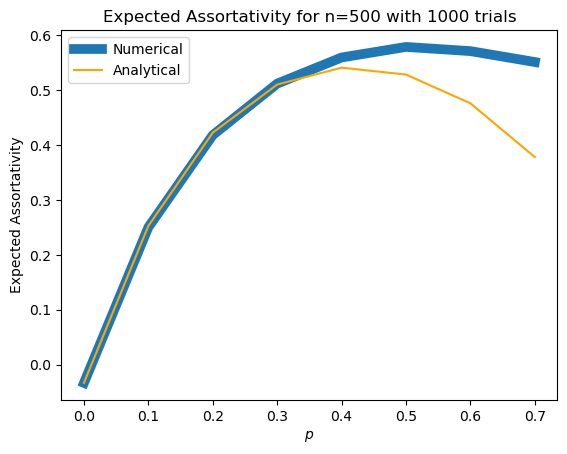

In [19]:
trials = 1000

p_list = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
t_list = np.zeros(len(p_list))
n = 500
expected = [assortativity_from_stub_matrix(evolve_stub_matrix(p, n)) for p in p_list]

for i, p in enumerate(p_list):
    for _ in range(trials):
        graph = create_all_or_none(p, n)
        G = nx.from_numpy_array(graph)
        t_list[i] += nx.degree_assortativity_coefficient(G)
    t_list[i] /= trials
    print(t_list[i], expected[i])

plt.plot(p_list, t_list, label="Numerical", linewidth=7.0)
plt.plot(p_list, expected, color="orange", label="Analytical")
plt.legend()
plt.title(f"Expected Assortativity for n={n} with {trials} trials")
plt.xlabel("$p$")
plt.ylabel("Expected Assortativity")

## Mean Shortest Path

In [20]:
def expected_avg_path_length(p, n):
    if n < 2:
        return 0.0
    
    # Harmonic number H_n ~ ln(n) + gamma + 1/(2n)
    gamma = 0.5772156649015329
    Hn = np.log(n) + gamma + 1/(2*n)
    
    term = (1 - p)*Hn + (5*p - 4)/2 + (2 - 3*p)/(n + 1)
    
    return (2*(n + 1)/(n - 1)) * term

[8.76887469 7.90566639 7.04245809 6.17924979 5.31604149 4.4528332
 3.5896249 ]
8.782244440881762
7.920734132264523
7.043193891783567
6.179711470941876
5.304389234468946
4.470152673346687
3.572090685370737


Text(0, 0.5, 'Expected Mean Shortest Path')

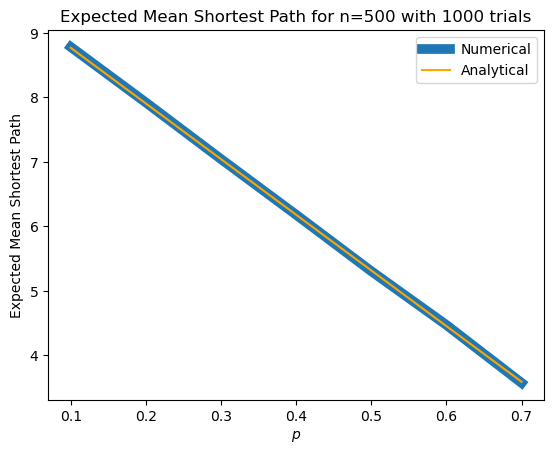

In [21]:
trials = 1000

p_list = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
t_list = np.zeros(len(p_list))
n = 500
expected = expected_avg_path_length(p_list, n)
print(expected)

for i, p in enumerate(p_list):
    for _ in range(trials):
        graph = create_all_or_none(p, n)
        G = nx.from_numpy_array(graph)
        t_list[i] += nx.average_shortest_path_length(G)
    t_list[i] /= trials
    print(t_list[i])

plt.plot(p_list, t_list, label="Numerical", linewidth=7.0)
plt.plot(p_list, expected, color="orange", label="Analytical")
plt.legend()
plt.title(f"Expected Mean Shortest Path for n={n} with {trials} trials")
plt.xlabel("$p$")
plt.ylabel("Expected Mean Shortest Path")

## Cliques

In [22]:
def cliques(p, n):
    ck = np.zeros(n)
    ck[0] = 2.0
    ck[1] = 1.0

    for t in range(2, n):
        nck = np.copy(ck)

        nck[0] += 1
        nck[1] += 1 + (2 * p / t) * ck[1]

        for i in range(2, n):
            k = i + 1
            nck[i] += (p / t) * (k * ck[i] + i * ck[i - 1])

        ck = nck

    return ck

CPU times: user 1.82 s, sys: 44.9 ms, total: 1.87 s
Wall time: 1.82 s


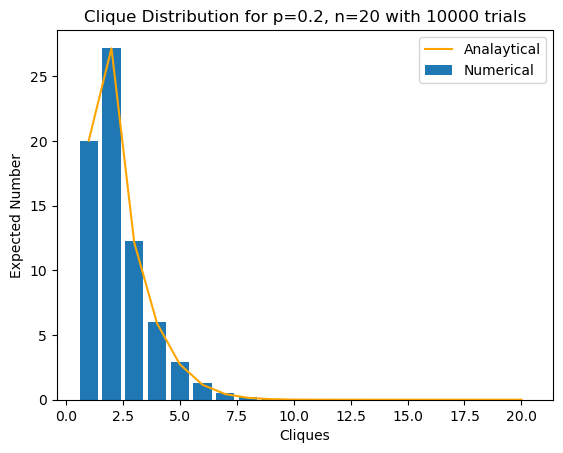

In [23]:
%%time
p, n = 0.2, 20

trials = 10000
count = np.zeros(n)
    
for _ in range(trials):
    for clique in nx.enumerate_all_cliques(nx.from_numpy_array(create_all_or_none(p, n))):
        count[len(clique) - 1] += 1 / trials

x = np.arange(n) + 1
plt.bar(x, count, label="Numerical")
plt.plot(x, cliques(p, n), color="orange", label="Analaytical")
plt.title(f"Clique Distribution for p={p}, n={n} with {trials} trials")
plt.xlabel("Cliques")
plt.ylabel("Expected Number")
plt.legend()

CPU times: user 6min 5s, sys: 760 ms, total: 6min 6s
Wall time: 6min 7s


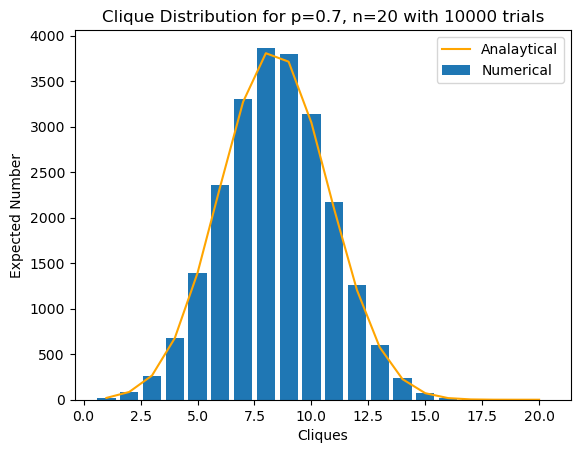

In [24]:
%%time
p, n = 0.7, 20

trials = 10000
count = np.zeros(n)
    
for _ in range(trials):
    for clique in nx.enumerate_all_cliques(nx.from_numpy_array(create_all_or_none(p, n))):
        count[len(clique) - 1] += 1 / trials

x = np.arange(n) + 1
plt.bar(x, count, label="Numerical")
plt.plot(x, cliques(p, n), color="orange", label="Analaytical")
plt.title(f"Clique Distribution for p={p}, n={n} with {trials} trials")
plt.xlabel("Cliques")
plt.ylabel("Expected Number")
plt.legend()

# Preferential Attachment Model

In [30]:
def create_pref(p, iterations):
    assert iterations > 1
    graph = np.zeros((iterations, iterations),dtype=np.int32)
    graph[0,1] = 1;
    graph[1,0] = 1;

    for i in range(2, iterations):
        weights = np.zeros(i)
        nodes = np.arange(i)
        for j in range(i):
            weights[j] = np.sum(graph[j,:])
        weights /= np.sum(weights)
        
        idx = np.random.choice(nodes, p=weights)
        if np.random.rand() < p:
            graph[:, i] = graph[:, idx]
            graph[i, :] = graph[idx, :]
            graph[i, idx] = 1
            graph[idx, i] = 1
        else:
            graph[idx, i] = 1
            graph[i, idx] = 1
    return graph

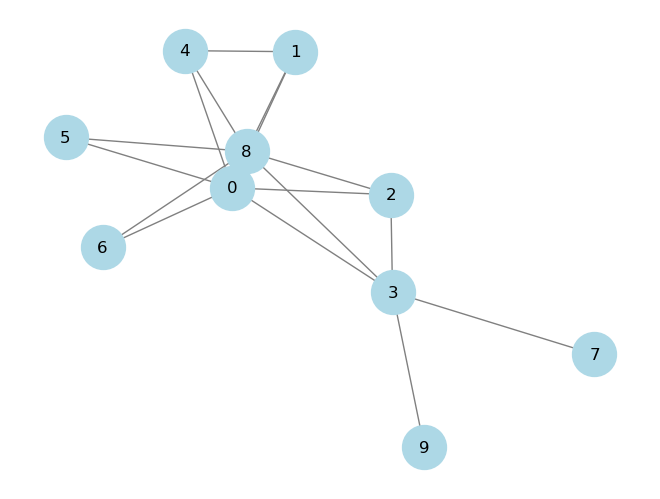

In [34]:
graph = create_pref(0.5, 10)

G = nx.from_numpy_array(graph)
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1000)
plt.show()

## Degree Distribution

In [36]:
def pref_degree_recur(p, n):
    dk = np.zeros(n - 1)
    dk[0] = 2
    for t in range(2, n):
        M = np.sum((np.arange(t) + 1) * dk[:t])
        M2 = np.sum((np.arange(t) + 1)**2 * dk[:t])
        
        dk_new = np.copy(dk)
        dk_new[0] = dk[0] + (1 - p)
        dk_new[0] -= (1 / M + p * 1 * M2 / M**2) * dk[0]
        for i in range(1, len(dk_new)):
            k = i + 1
            dk_new[i] = dk[i]
            dk_new[i] += ((k-1) / M + p * (k - 1) * M2 / M**2) * dk[i - 1]
            dk_new[i] -= (k / M + p * k * M2 / M**2) * dk[i]
            dk_new[i] += p * (k - 1) * dk[i - 1] / M
        dk = dk_new

    return dk

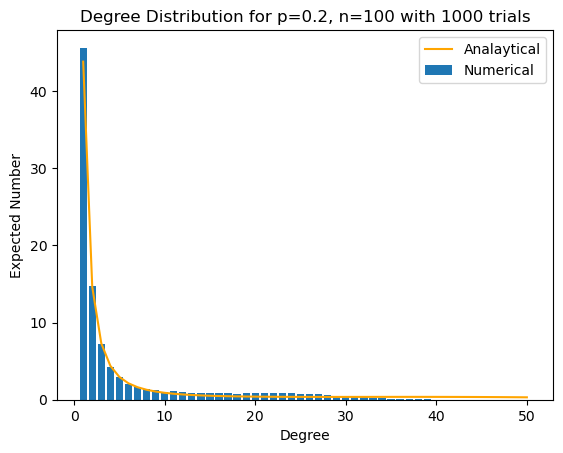

In [42]:
from collections import Counter
cnt = Counter()
trials = 1000

p, n, cutoff = 0.2, 100, 50
dk = np.zeros(n - 1)

for _ in range(trials):
    graph = create_pref(p, n)
    G = nx.from_numpy_array(graph)
    for _, d in G.degree():
        dk[d - 1] += 1

dk /= trials
x = np.arange(n) + 1
x = x[:cutoff]
plt.bar(x, dk[:cutoff], label="Numerical")
plt.plot(x, pref_degree_recur(p, n)[:cutoff], color="orange", label="Analaytical")
plt.title(f"Degree Distribution for p={p}, n={n} with {trials} trials")
plt.xlabel("Degree")
plt.ylabel("Expected Number")
plt.legend()

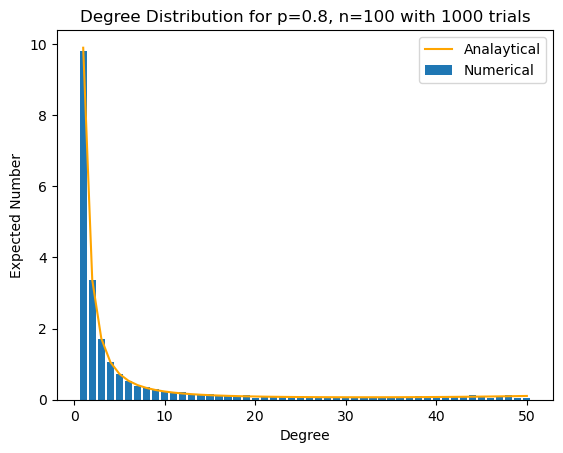

In [43]:
from collections import Counter
cnt = Counter()
trials = 1000

p, n, cutoff = 0.8, 100, 50
dk = np.zeros(n - 1)

for _ in range(trials):
    graph = create_pref(p, n)
    G = nx.from_numpy_array(graph)
    for _, d in G.degree():
        dk[d - 1] += 1

dk /= trials
x = np.arange(n) + 1
x = x[:cutoff]
plt.bar(x, dk[:cutoff], label="Numerical")
plt.plot(x, pref_degree_recur(p, n)[:cutoff], color="orange", label="Analaytical")
plt.title(f"Degree Distribution for p={p}, n={n} with {trials} trials")
plt.xlabel("Degree")
plt.ylabel("Expected Number")
plt.legend()